<a href="https://colab.research.google.com/github/shankar516/Retail-Customer-Segmentation-RFM/blob/main/Retail_Customer_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd

# Load the Excel file
# Note: It might take 30-60 seconds because the file is about 50MB
df = pd.read_excel('Online Retail.xlsx')

# This shows us the first 5 rows and the column names
print("Step 1 Complete! Here is a preview of your data:")
df.head()

BadZipFile: File is not a zip file

In [8]:
# 1. Remove rows where CustomerID is missing
df = df.dropna(subset=['CustomerID'])

# 2. Keep only rows where Quantity and UnitPrice are greater than 0
# This removes returns and "bad" data
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# 3. Create a 'TotalSum' column (Price * Quantity)
df['TotalSum'] = df['Quantity'] * df['UnitPrice']

# 4. Convert InvoiceDate to a proper 'DateTime' format (just in case)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Step 2 Complete! Data is now clean.")
print(f"Number of rows remaining: {df.shape[0]}")
df.head()

Step 2 Complete! Data is now clean.
Number of rows remaining: 397884


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSum
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [9]:
import datetime as dt

# 1. We need a "Snapshot Date" to calculate Recency.
# We'll use the day after the very last sale in the dataset.
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# 2. Group everything by CustomerID
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'count',                                   # Frequency
    'TotalSum': 'sum'                                       # Monetary
})

# 3. Rename the columns so they make sense
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSum': 'Monetary'
}, inplace=True)

print("Step 3 Complete! Your RFM table is ready.")
rfm.head()

Step 3 Complete! Your RFM table is ready.


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [10]:
# 1. We use pd.qcut to divide the data into 5 equal parts (quantiles)
# Note: For Recency, 1 is the 'best' (lowest days), so we use labels=[5,4,3,2,1]
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

# For Frequency and Monetary, 5 is the 'best' (highest numbers)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# 2. Combine the scores into one "RFM_Score" (like '555' or '111')
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str)

print("Step 4 Complete! Customers are now ranked.")
rfm.head()

Step 4 Complete! Customers are now ranked.


,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,11
12347.0,2,182,4310.00,5,5,5,55
12348.0,75,31,1797.24,2,3,4,23
12349.0,19,73,1757.55,4,4,4,44
12350.0,310,17,334.40,1,2,2,12


In [11]:
# Create a dictionary for mapping scores to names
# R_Score is the first digit, F_Score is the second digit
seg_map = {
    r'[1-2][1-2]': 'hibernating',
    r'[1-2][3-4]': 'at_Risk',
    r'[1-2]5': 'cant_loose',
    r'3[1-2]': 'about_to_sleep',
    r'33': 'need_attention',
    r'[3-4][4-5]': 'loyal_customers',
    r'41': 'promising',
    r'51': 'new_customers',
    r'[4-5][2-3]': 'potential_loyalists',
    r'5[4-5]': 'champions'
}

# Apply the segment names to the RFM_Score
rfm['segment'] = rfm['RFM_Score'].replace(seg_map, regex=True)

print("Step 5 Complete! Your customers have names.")
rfm.head()

Step 5 Complete! Your customers have names.


,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,5,11,hibernating
12347.0,2,182,4310.00,5,5,5,55,champions
12348.0,75,31,1797.24,2,3,4,23,at_Risk
12349.0,19,73,1757.55,4,4,4,44,loyal_customers
12350.0,310,17,334.40,1,2,2,12,hibernating


/tmp/ipython-input-603/3187756621.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, y='segment', order=rfm['segment'].value_counts().index, palette='viridis')


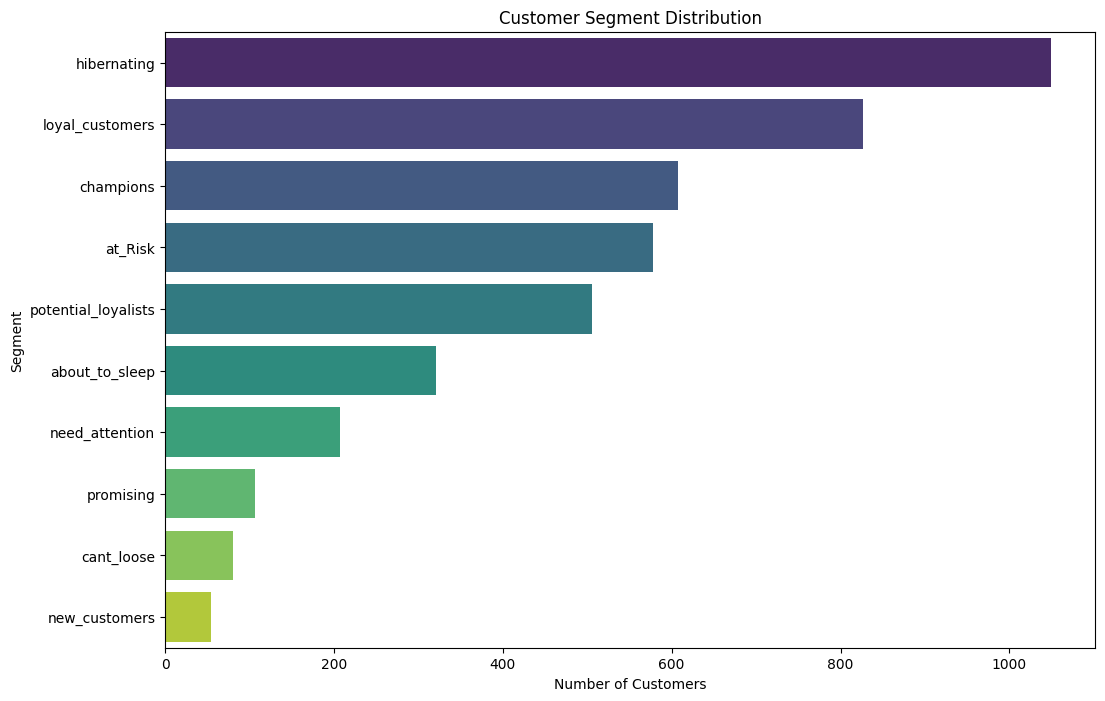

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.countplot(data=rfm, y='segment', order=rfm['segment'].value_counts().index, palette='viridis')
plt.title('Customer Segment Distribution')
plt.xlabel('Number of Customers')
plt.ylabel('Segment')
plt.show()

In [13]:
# 1. Group by the segment name and calculate the total and average money spent
segment_stats = rfm.groupby('segment').agg({
    'Monetary': ['sum', 'mean', 'count']
}).round(1)

# 2. Rename columns to make them easy to read
segment_stats.columns = ['Total_Revenue', 'Average_Spend', 'Number_of_Customers']

# 3. Sort by Total Revenue to see who brings in the most cash
segment_stats = segment_stats.sort_values(by='Total_Revenue', ascending=False)

print("Financial Summary of your Customers:")
segment_stats

Financial Summary of your Customers:


,Total_Revenue,Average_Spend,Number_of_Customers
segment,,,
champions,4218732.0,6950.1,607
loyal_customers,2336844.8,2825.7,827
at_Risk,569172.9,984.7,578
hibernating,556892.1,530.9,1049
potential_loyalists,455641.2,900.5,506
new_customers,205817.3,3742.1,55
cant_loose,193875.1,2393.5,81
need_attention,175565.7,848.1,207
about_to_sleep,152570.3,475.3,321


In [14]:
# 1. Create a specific list of only 'at_Risk' customers
at_risk_list = rfm[rfm['segment'] == 'at_Risk']

# 2. Save this list to a CSV file on your Google Colab
at_risk_list.to_csv('at_risk_customers.csv')

# 3. Save the FULL analysis too
rfm.to_csv('final_customer_segmentation.csv')

print("Success! Your files are ready.")
print(f"You have {len(at_risk_list)} customers in your 'At Risk' file.")

Success! Your files are ready.
You have 578 customers in your 'At Risk' file.


In [7]:
import pandas as pd

# This link goes directly to the raw data on the UCI server
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'

print("Starting download... this usually takes about 30 seconds.")

# We load it directly into 'df'
df = pd.read_excel(url)

print("Success! Step 1 is officially complete.")
df.head()

Starting download... this usually takes about 30 seconds.
Success! Step 1 is officially complete.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
